In [18]:
import pandas as pd

df = pd.read_csv("../data/raw/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [19]:
df.shape

(1067371, 8)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [21]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [22]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [23]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [24]:
df["Revenue"] = df["Quantity"] * df["Price"]

df[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [25]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["InvoiceDate"].head()

0   2009-12-01 07:45:00
1   2009-12-01 07:45:00
2   2009-12-01 07:45:00
3   2009-12-01 07:45:00
4   2009-12-01 07:45:00
Name: InvoiceDate, dtype: datetime64[ns]

In [26]:
print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())

Start Date: 2009-12-01 07:45:00
End Date: 2011-12-09 12:50:00


In [27]:
df["Revenue"].sum()

np.float64(19287250.56799999)

In [28]:
df["Customer ID"].nunique()

5942

In [29]:
df["Description"].nunique()

5698

<Axes: xlabel='Description'>

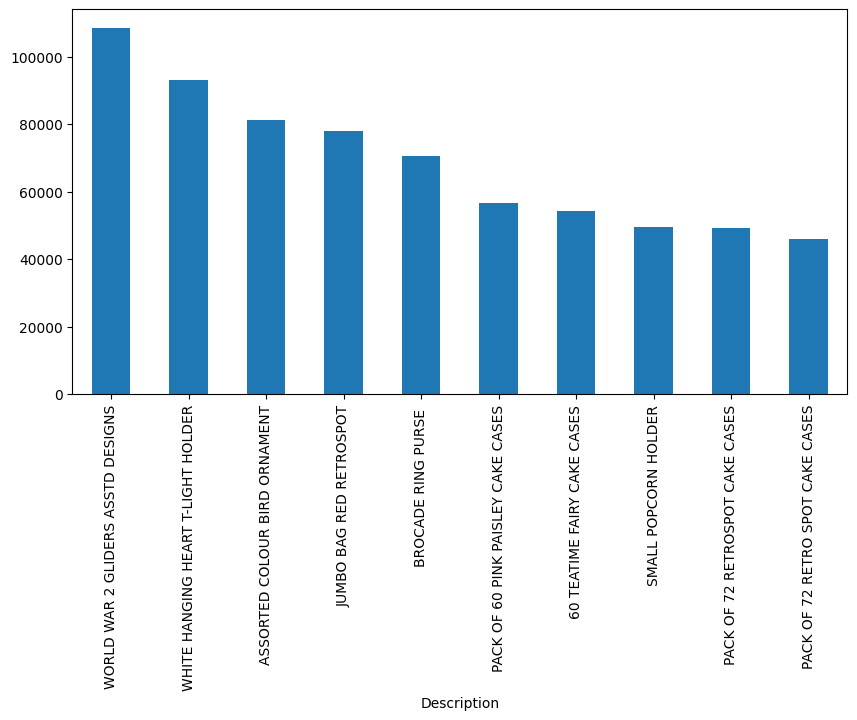

In [30]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar", figsize=(10,5))

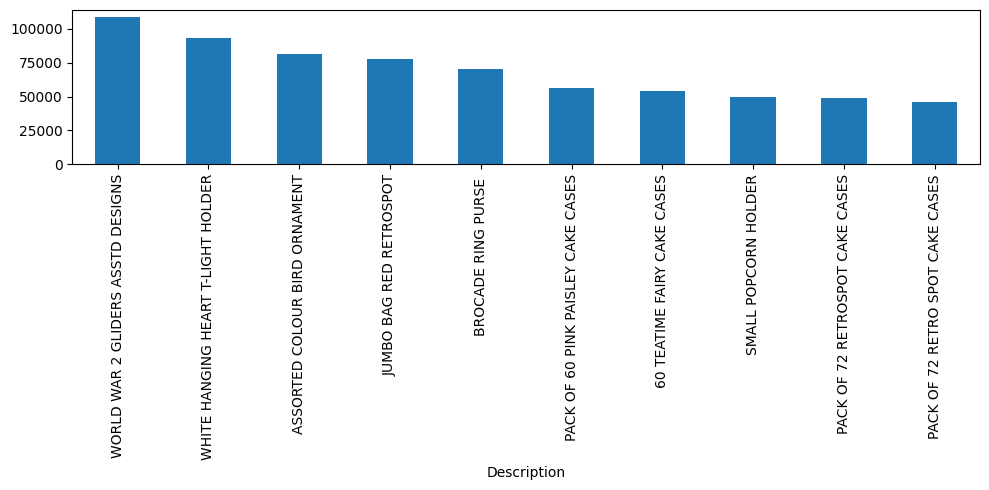

In [31]:
top_products.plot(kind="bar", figsize=(10,5))

import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig("../screenshots/top_10_selling_products.png")
plt.show()

In [32]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

<Axes: xlabel='Month'>

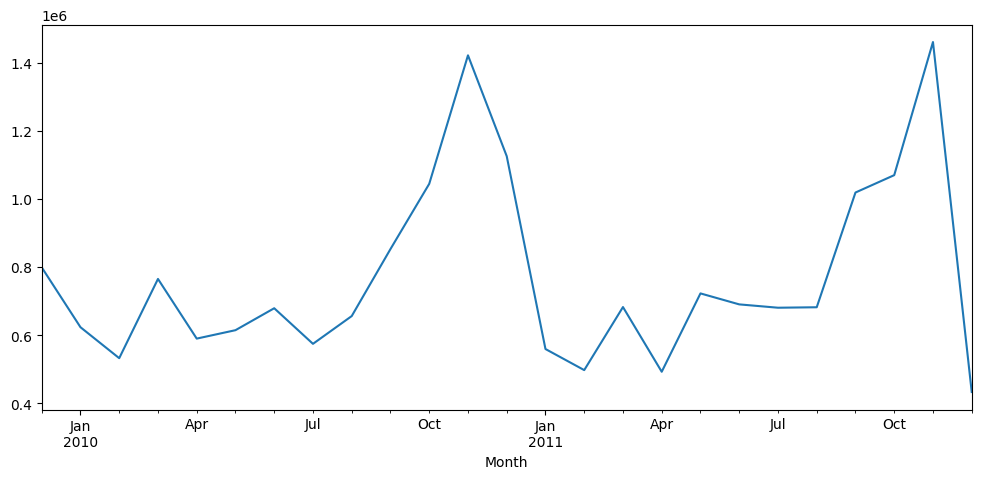

In [33]:
monthly_sales = df.groupby("Month")["Revenue"].sum()

monthly_sales.plot(figsize=(12,5))

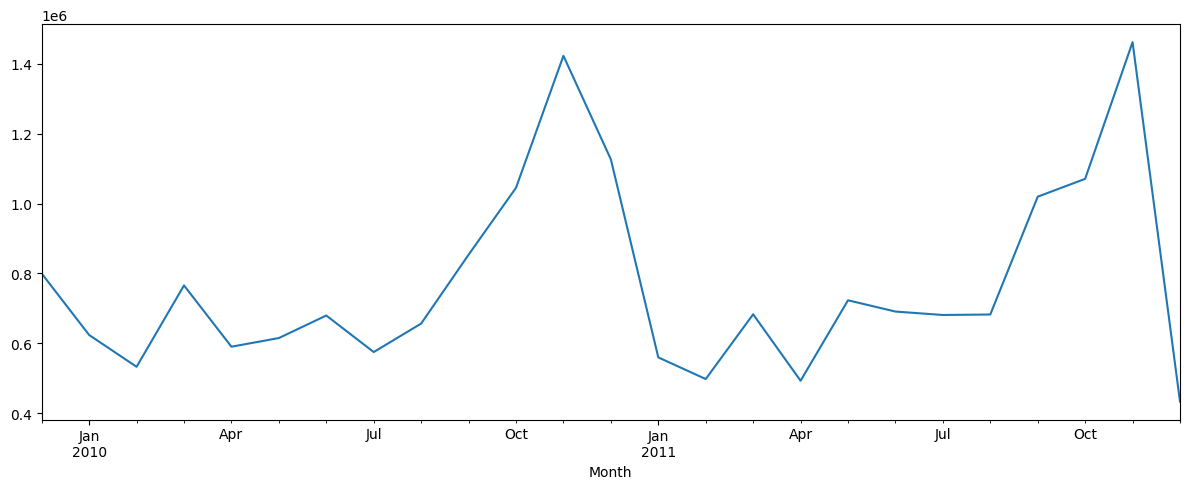

In [34]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(12,5))
plt.tight_layout()
plt.savefig("../screenshots/monthly_sales_trend.png")
plt.show()